In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('data_clean/cleaned_ecommerce.csv')

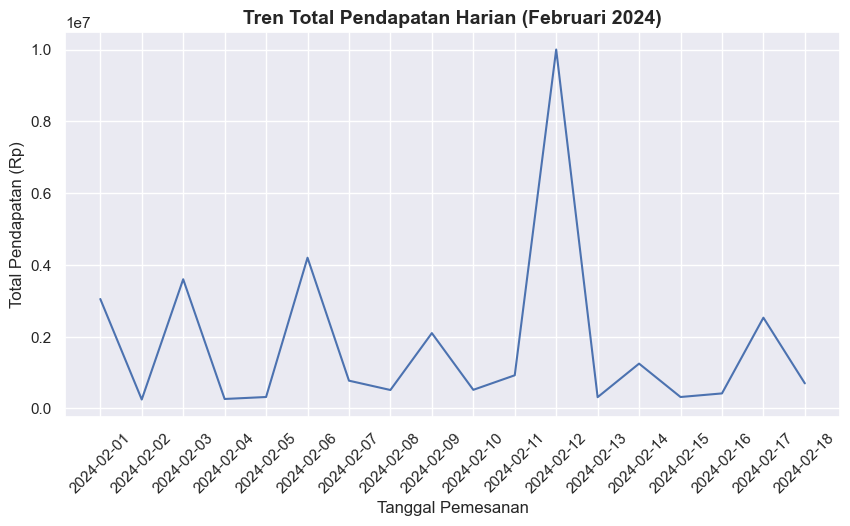

In [3]:
# Tren Penjualan Harian
# Mengelompokkan data berdasarkan Order_Date, lalu jumlahkan Final_Amount-nya
tren_harian = df.groupby('Order_Date')['Final_Amount'].sum().reset_index()

# Buat ukuran kanvas (luas = 10, tinggi = 5)
plt.figure(figsize=(10, 5))

sns.set_theme(style="darkgrid") # Menggunakan tema gelap

# Membuat grafik garis
sns.lineplot(
    data=tren_harian,
    x='Order_Date', # Horizontal
    y='Final_Amount', # Vertikal
)

plt.title('Tren Total Pendapatan Harian (Februari 2024)', fontsize=14, fontweight='bold') # Memberikan judul pada grafik
plt.xlabel('Tanggal Pemesanan', fontsize=12) # Memberikan label pada sumbu horizontal
plt.ylabel('Total Pendapatan (Rp)', fontsize=12) # Memberikan label pada sumbu vertikal

# Miringkan tulisan tanggal di sumbu X sebesar 45 derajat agar tidak tabrakan
plt.xticks(rotation=45)

# Menampilkan grafik
plt.show() # Menampilkan

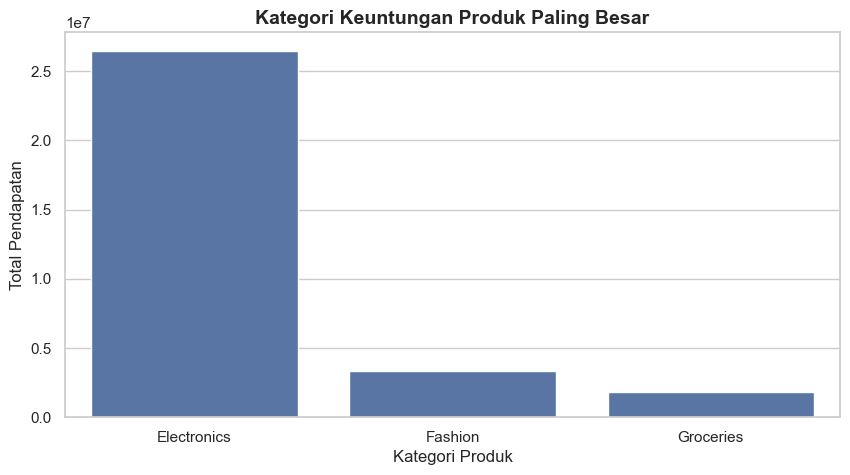

In [4]:
# Kategori Produk Paling Menguntungkan
kategori_produk_keuntungan = df.groupby('Product_Category')['Total_Sales'].sum().reset_index().sort_values(by='Total_Sales', ascending=False)

# Buat ukuran kanvas (luas = 10, tinggi = 5)
plt.figure(figsize=(10, 5))

sns.set_theme(style='whitegrid') # Menggunakan tema gelap

# Membuat grafik batang
sns.barplot(
    data=kategori_produk_keuntungan,
    x='Product_Category', # Horizontal
    y='Total_Sales' # Vertikal
)

plt.title('Kategori Keuntungan Produk Paling Besar', fontsize=14, fontweight='bold') # Judul
plt.xlabel('Kategori Produk') # Label pada horizontal
plt.ylabel('Total Pendapatan') # Label pada vertikal

plt.show() # Menampilkan

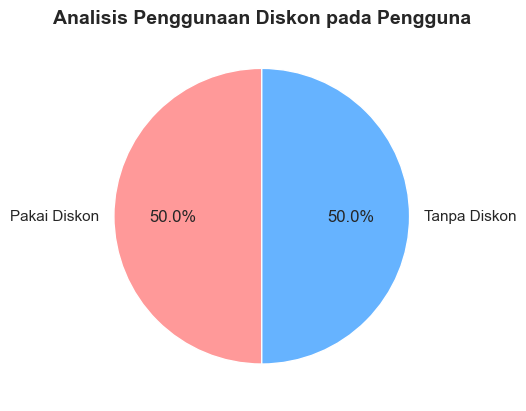

In [5]:
# Analisis Penggunaan Diskon
def penggunaanDiskon(teks) :
    if pd.isna(teks) :
        return "Tanpa Diskon"
    else :
        return "Pakai Diskon"
            
df['Status_Promo'] = df['Discount_Code'].apply(penggunaanDiskon)
status_penggunaan_promo = df['Status_Promo'].value_counts() # Menghitung jumlah frekuensi nilai

# Memanggil plot.pie() langsung dari variabel yang berisi perhitungan yaitu status_penggunaan_promo
status_penggunaan_promo.plot.pie(
    autopct='%1.1f%%',         # Menambahkan label persentase (1 angka di belakang koma)
    startangle=90,             # Memutar posisi awal pie chart agar tampilannya lebih proporsional
    colors=['#ff9999', '#66b3ff']  # Memberikan warna 
)

# Menghapus tulisan count pada 'Status_Promo' yang muncul di pinggiran chart
plt.ylabel('')
plt.title('Analisis Penggunaan Diskon pada Pengguna', fontsize=14, fontweight='bold') # Judul

plt.show()

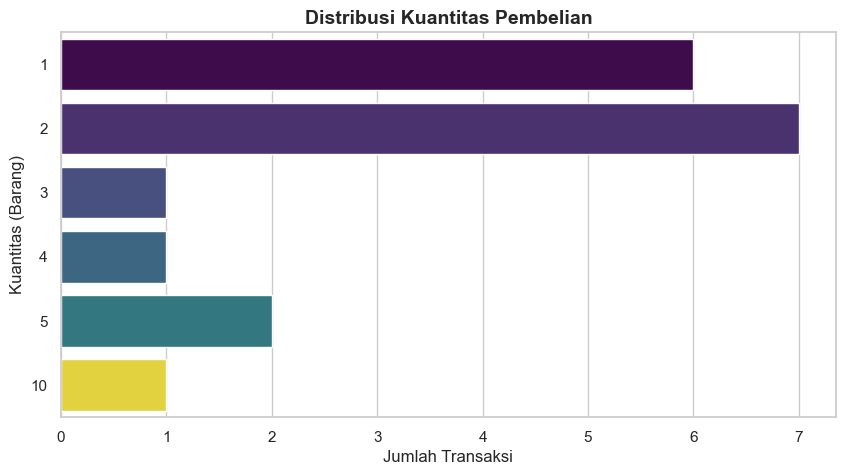

In [6]:
# Distribusi Kuantitas Pembelian
plt.figure(figsize=(10, 5))

"""
hue= memecah satu batang menjadi beberapa warna;
Contoh: memecah batang "Kuantitas" menjadi warna biru untuk Pria dan merah untuk Wanita

legends= membuang kotak keterangan warna di pojok grafik
"""
#  
sns.countplot(y='Quantity', data=df, hue='Quantity', palette='viridis', legend=False)

plt.title('Distribusi Kuantitas Pembelian', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Transaksi') # Label horizontal
plt.ylabel('Kuantitas (Barang)') # Label Vertikal
 
plt.show()